# Resume Text Classification Project

This notebook presents a clean workflow for resume text classification using TF-IDF feature engineering and fast baseline model comparison.

## Section 1: Data

In this section, we load the Kaggle Resume Dataset and inspect the basic dataset structure.

In [26]:
import os
import re
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.base import clone
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
%matplotlib inline

OUTPUT_DIR = 'outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)
sns.set_theme(style='whitegrid')

df = pd.read_csv('Resume/Resume.csv')
print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (2484, 4)


,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


## Section 2: Preprocessing

Here we clean the resume text by lowercasing, removing non-letter characters, and reducing extra spaces.

In [18]:
def clean_resume_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


def shorten_text(text, max_length=180):
    text = str(text).replace('\n', ' ').strip()
    if len(text) <= max_length:
        return text
    return text[:max_length] + '...'


df['Clean_Resume'] = df['Resume_str'].apply(clean_resume_text)
pd.DataFrame({
    'Original Text': df['Resume_str'].head(3).apply(lambda x: shorten_text(x, 160)),
    'Cleaned Text': df['Clean_Resume'].head(3).apply(lambda x: shorten_text(x, 160))
})

,Original Text,Cleaned Text
0,HR ADMINISTRATOR/MARKETING ASSOCIATE HR ADMIN...,hr administratormarketing associate hr adminis...
1,"HR SPECIALIST, US HR OPERATIONS Summary ...",hr specialist us hr operations summary versati...
2,HR DIRECTOR Summary Over 20 years e...,hr director summary over years experience in r...


## Section 3: Feature Engineering

We convert cleaned resume text into TF-IDF vectors and show readable examples of how the representation changes after feature engineering.

In [19]:
X = df['Clean_Resume']
y = df['Category']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
train_df = train_df.copy()
test_df = test_df.copy()

vectorizer = TfidfVectorizer(max_features=1000, stop_words='english')
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(vectorizer.get_feature_names_out()[:20])

['ability' 'able' 'academic' 'access' 'accomplishments' 'accordance'
 'according' 'account' 'accountant' 'accounting' 'accounts' 'accuracy'
 'accurate' 'accurately' 'achieve' 'achieved' 'achievement' 'acquisition'
 'action' 'actions']


In [20]:
def get_top_tfidf_features(vectorizer_obj, vector_row, top_n=8):
    feature_names = vectorizer_obj.get_feature_names_out()
    row_array = vector_row.toarray().flatten()
    non_zero_indices = np.where(row_array > 0)[0]
    if len(non_zero_indices) == 0:
        return []
    top_indices = non_zero_indices[np.argsort(row_array[non_zero_indices])[::-1][:top_n]]
    return [(feature_names[i], float(row_array[i])) for i in top_indices]


def format_tfidf_representation(vectorizer_obj, vector_row, top_n=8):
    top_features = get_top_tfidf_features(vectorizer_obj, vector_row, top_n=top_n)
    if not top_features:
        return 'No non-zero TF-IDF features'
    return ', '.join([f'{feature} ({score:.3f})' for feature, score in top_features])


def create_feature_examples_df(original_texts, cleaned_texts, vectorizer_obj, num_examples=3):
    transformed = vectorizer_obj.transform(cleaned_texts.iloc[:num_examples])
    rows = []
    for i in range(min(num_examples, len(cleaned_texts))):
        rows.append({
            'Original Text': shorten_text(original_texts.iloc[i], 180),
            'Cleaned Text': shorten_text(cleaned_texts.iloc[i], 180),
            'TF-IDF Representation': format_tfidf_representation(vectorizer_obj, transformed[i], top_n=8)
        })
    return pd.DataFrame(rows)


create_feature_examples_df(train_df['Resume_str'], train_df['Clean_Resume'], vectorizer, num_examples=3)

,Original Text,Cleaned Text,TF-IDF Representation
0,GRADUATE ENGINEER Summary Intellectua...,graduate engineer summary intellectually curio...,"engineering (0.363), transportation (0.325), d..."
1,OFFICE MANAGER/MANAGING DIRECTOR Profess...,office managermanaging director professional s...,"patient (0.468), care (0.356), patients (0.246..."
2,"SALES CONSULTANT, INTERIOR DESIGNER Pr...",sales consultant interior designer professiona...,"sales (0.366), designer (0.320), presentations..."


## Section 4: Training

We compare a small set of fast models using the same TF-IDF settings, select the best model based on validation accuracy, and retrain it on the full training set.

In [21]:
def evaluate_candidate_models(X_train_part, y_train_part, X_val_part, y_val_part, candidates):
    results = []
    for config in candidates:
        pipeline = Pipeline([
            ('tfidf', TfidfVectorizer(
                max_features=config['max_features'],
                ngram_range=config['ngram_range'],
                stop_words='english'
            )),
            ('classifier', clone(config['model']))
        ])
        pipeline.fit(X_train_part, y_train_part)
        val_predictions = pipeline.predict(X_val_part)
        val_accuracy = accuracy_score(y_val_part, val_predictions)
        results.append({
            'name': config['name'],
            'pipeline': pipeline,
            'validation_accuracy': val_accuracy,
            'max_features': config['max_features'],
            'ngram_range': config['ngram_range']
        })
    return sorted(results, key=lambda item: item['validation_accuracy'], reverse=True)


train_sub_df, val_df = train_test_split(
    train_df,
    test_size=0.2,
    random_state=42,
    stratify=train_df['Category']
)

candidate_models = [
    {
        'name': 'Multinomial Naive Bayes | TF-IDF(1,1), max_features=3000, alpha=1.0',
        'max_features': 3000,
        'ngram_range': (1, 1),
        'model': MultinomialNB(alpha=1.0)
    },
    {
        'name': 'Multinomial Naive Bayes | TF-IDF(1,2), max_features=3000, alpha=1.0',
        'max_features': 3000,
        'ngram_range': (1, 2),
        'model': MultinomialNB(alpha=1.0)
    },
    {
        'name': 'Linear SVM | TF-IDF(1,1), max_features=3000, C=1',
        'max_features': 3000,
        'ngram_range': (1, 1),
        'model': LinearSVC(C=1.0, random_state=42)
    },
    {
        'name': 'Linear SVM | TF-IDF(1,2), max_features=3000, C=1',
        'max_features': 3000,
        'ngram_range': (1, 2),
        'model': LinearSVC(C=1.0, random_state=42)
    }
]

comparison_results = evaluate_candidate_models(
    train_sub_df['Clean_Resume'],
    train_sub_df['Category'],
    val_df['Clean_Resume'],
    val_df['Category'],
    candidate_models
)

comparison_df = pd.DataFrame([
    {
        'Model / Features': result['name'],
        'Validation Accuracy': round(result['validation_accuracy'], 4)
    }
    for result in comparison_results
])
comparison_df

,Model / Features,Validation Accuracy
0,"Linear SVM | TF-IDF(1,2), max_features=3000, C=1",0.6583
1,"Linear SVM | TF-IDF(1,1), max_features=3000, C=1",0.6407
2,"Multinomial Naive Bayes | TF-IDF(1,2), max_fea...",0.5327
3,"Multinomial Naive Bayes | TF-IDF(1,1), max_fea...",0.5251


In [22]:
best_result = comparison_results[0]
print(f"Selected model: {best_result['name']}")
print(f"Validation accuracy: {best_result['validation_accuracy']:.4f}")

best_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=best_result['max_features'],
        ngram_range=best_result['ngram_range'],
        stop_words='english'
    )),
    ('classifier', clone(best_result['pipeline'].named_steps['classifier']))
])
best_pipeline.fit(train_df['Clean_Resume'], train_df['Category'])

Selected model: Linear SVM | TF-IDF(1,2), max_features=3000, C=1
Validation accuracy: 0.6583


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('tfidf', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


## Section 5: Evaluation

Finally, we apply the selected model to the test set, inspect the first predictions, and evaluate overall performance using accuracy, a classification report, and a confusion matrix heatmap.

In [23]:
y_test_pred = best_pipeline.predict(test_df['Clean_Resume'])
test_accuracy = accuracy_score(test_df['Category'], y_test_pred)

first_five_predictions = pd.DataFrame({
    'Index': test_df.index[:5],
    'Short Text Snippet': [shorten_text(text, 120) for text in test_df['Resume_str'].iloc[:5]],
    'True Label': test_df['Category'].iloc[:5].values,
    'Predicted Label': y_test_pred[:5]
})

print(f'Test Accuracy: {test_accuracy:.4f}')
print('\nClassification Report:')
print(classification_report(test_df['Category'], y_test_pred, zero_division=0))
first_five_predictions

Test Accuracy: 0.7042

Classification Report:
                        precision    recall  f1-score   support

            ACCOUNTANT       0.82      0.93      0.87        29
              ADVOCATE       0.63      0.73      0.68        30
           AGRICULTURE       0.20      0.12      0.15         8
               APPAREL       0.52      0.55      0.54        20
                  ARTS       0.36      0.22      0.28        18
            AUTOMOBILE       0.33      0.17      0.22         6
              AVIATION       0.82      0.86      0.84        21
               BANKING       0.76      0.70      0.73        23
                   BPO       0.50      0.50      0.50         2
  BUSINESS-DEVELOPMENT       0.91      0.74      0.82        27
                  CHEF       1.00      0.71      0.83        24
          CONSTRUCTION       0.88      0.82      0.85        34
            CONSULTANT       0.47      0.45      0.46        20
              DESIGNER       0.77      0.89      0.83    

,Index,Short Text Snippet,True Label,Predicted Label
0,420,Kpandipou Koffi Summary Compas...,TEACHER,HEALTHCARE
1,1309,DIRECTOR OF DIGITAL TRANSFORMATION Execu...,DIGITAL-MEDIA,DIGITAL-MEDIA
2,2023,SENIOR PROJECT MANAGER Professional Summ...,CONSTRUCTION,CONSTRUCTION
3,1360,CHEF Summary Experienced catering ch...,CHEF,CHEF
4,2186,OPERATIONS MANAGER Summary Experience...,BANKING,BANKING


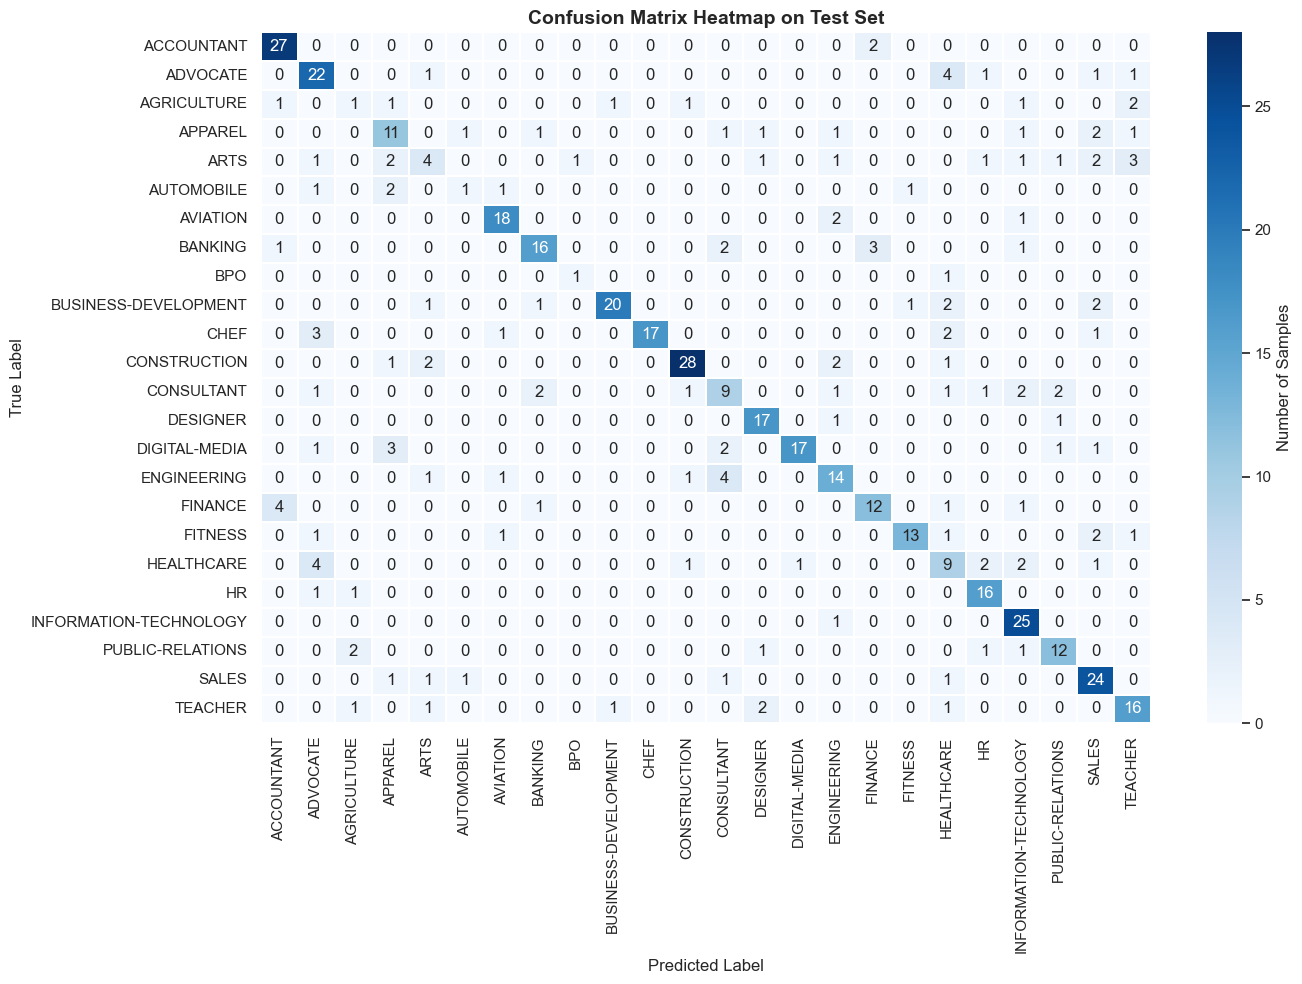

In [28]:
labels = sorted(test_df['Category'].unique())
cm = confusion_matrix(test_df['Category'], y_test_pred, labels=labels)
cm_df = pd.DataFrame(cm, index=labels, columns=labels)

plt.figure(figsize=(14, 10))
sns.heatmap(
    cm_df,
    cmap='Blues',
    annot=True,
    fmt='d',
    linewidths=0.2,
    linecolor='white',
    cbar_kws={'label': 'Number of Samples'}
)
plt.title('Confusion Matrix Heatmap on Test Set', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', bbox_inches='tight')
